# Módulo 4: Canal Selectivo en Frecuencia

Este notebook agrega un canal selectivo en frecuencia (multipath) al sistema LoRa,
combinándolo con el ruido AWGN del Módulo 3. Se analiza cómo la distorsión espectral
afecta la BER y se compara contra el canal AWGN puro.

## Contenido

1. Función de canal multipath (convolución con respuesta al impulso)
2. Visualización de la respuesta en frecuencia del canal
3. Efecto del canal sobre un chirp
4. Canal completo: multipath + AWGN
5. Barrido BER vs SNR con canal selectivo
6. Comparación contra canal AWGN puro


## 1. Librerías e imports de módulos anteriores

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Módulo 1 ----------

def codificador(bits, SF):
    bits = np.array(bits)
    if len(bits) % SF != 0:
        raise ValueError(f"La cantidad de bits ({len(bits)}) debe ser múltiplo de SF ({SF})")
    num_simbolos = len(bits) // SF
    simbolos = np.zeros(num_simbolos, dtype=int)
    for i in range(num_simbolos):
        bloque = bits[i * SF : (i + 1) * SF]
        valor = 0
        for posicion, bit in enumerate(bloque):
            peso = 2 ** (SF - 1 - posicion)
            valor += bit * peso
        simbolos[i] = valor
    return simbolos

def decodificador(simbolos, SF):
    simbolos = np.array(simbolos, dtype=int)
    bits = np.zeros(len(simbolos) * SF, dtype=int)
    for i, simbolo in enumerate(simbolos):
        valor_restante = int(simbolo)
        for posicion in range(SF):
            peso = 2 ** (SF - 1 - posicion)
            if valor_restante >= peso:
                bits[i * SF + posicion] = 1
                valor_restante -= peso
    return bits

def calcular_ber(bits_tx, bits_rx):
    bits_tx = np.array(bits_tx)
    bits_rx = np.array(bits_rx)
    if len(bits_tx) != len(bits_rx):
        raise ValueError("Los vectores deben tener la misma longitud")
    return np.sum(bits_tx != bits_rx) / len(bits_tx)

# ---------- Módulo 2 ----------

def up_chirp_base(SF, BW, Fs):
    N = 2**SF
    chirp = np.zeros(N, dtype=complex)
    for k in range(N):
        argumento = k**2 / (2*N) - k/2
        chirp[k] = np.exp(1j * 2 * np.pi * argumento)
    return chirp

def down_chirp(SF, BW, Fs):
    return np.conj(up_chirp_base(SF, BW, Fs))

def waveform_former(simbolos, SF, BW, Fs):
    N = 2**SF
    simbolos = np.array(simbolos)
    chirp_base = up_chirp_base(SF, BW, Fs)
    waveform = np.zeros((len(simbolos), N), dtype=complex)
    for i, s in enumerate(simbolos):
        waveform[i] = np.roll(chirp_base, -s)
    return waveform

def n_tuple_former(waveform, SF, BW, Fs):
    dc = down_chirp(SF, BW, Fs)
    num_simbolos = waveform.shape[0]
    simbolos_rx = np.zeros(num_simbolos, dtype=int)
    for i in range(num_simbolos):
        dechirped = waveform[i] * dc
        espectro = np.fft.fft(dechirped)
        simbolos_rx[i] = np.argmax(np.abs(espectro))
    return simbolos_rx

# ---------- Módulo 3 ----------

def agregar_ruido_awgn(waveform, snr_db):
    potencia_senal = np.mean(np.abs(waveform)**2)
    snr_lineal = 10 ** (snr_db / 10)
    potencia_ruido = potencia_senal / snr_lineal
    desviacion = np.sqrt(potencia_ruido / 2)
    ruido = desviacion * (np.random.randn(*waveform.shape) +
                          1j * np.random.randn(*waveform.shape))
    return waveform + ruido

# ---------- Parámetros ----------
SF = 7
BW = 125e3
Fs = BW
N  = 2**SF

print("Módulos 1, 2 y 3 cargados correctamente.")
print(f"Parámetros: SF={SF}, BW={BW/1e3:.0f} kHz, N={N}")

Módulos 1, 2 y 3 cargados correctamente.
Parámetros: SF=7, BW=125 kHz, N=128


## 2. Modelo del canal multipath

Un canal multipath se describe por su **respuesta al impulso** `h`:
una lista de coeficientes complejos, donde cada uno representa un camino de propagación.

- El **índice** de cada coeficiente es su retardo en muestras
- La **magnitud** es la atenuación de ese camino
- La **fase** es el desfase introducido por ese camino

Aplicar el canal es simplemente **convolucionar** la señal con `h`.
La convolución suma todas las copias retardadas y atenuadas de la señal:

$$y[n] = \sum_{l=0}^{L-1} h[l] \cdot x[n-l]$$

> Usar el h del paper
>
Usamos un canal de 3 caminos como ejemplo representativo:
- Camino 0: llegada directa, sin retardo, atenuación 1.0
- Camino 1: primer rebote, retardo de 5 muestras, atenuación 0.5 con desfase
- Camino 2: segundo rebote, retardo de 10 muestras, atenuación 0.3 con desfase


In [2]:
def crear_canal_multipath(retardos, atenuaciones, fases_deg):
    """
    Crea la respuesta al impulso de un canal multipath.

    Parámetros
    ----------
    retardos     : lista de retardos en muestras [0, 5, 10, ...]
    atenuaciones : lista de amplitudes            [1.0, 0.5, 0.3, ...]
    fases_deg    : lista de fases en grados       [0, 45, 90, ...]

    Retorna
    -------
    h : np.array complejo con la respuesta al impulso
        (longitud = retardo máximo + 1)
    """
    longitud = max(retardos) + 1
    h = np.zeros(longitud, dtype=complex)

    for retardo, atenuacion, fase in zip(retardos, atenuaciones, fases_deg):
        # Cada camino es una atenuación compleja: amplitud × e^(j×fase)
        fase_rad = fase * np.pi / 180
        h[retardo] = atenuacion * np.exp(1j * fase_rad)

    return h

# Canal de ejemplo: 3 caminos
retardos     = [0,    5,    10  ]
atenuaciones = [1.0,  0.5,  0.3 ]
fases_deg    = [0,    45,   90  ]

h = crear_canal_multipath(retardos, atenuaciones, fases_deg)

print("Respuesta al impulso h:")
for i, coef in enumerate(h):
    if abs(coef) > 0:
        print(f"  h[{i}] = {coef:.4f}  "
              f"(|h|={abs(coef):.3f}, fase={np.angle(coef)*180/np.pi:.1f}°)")

Respuesta al impulso h:
  h[0] = 1.0000+0.0000j  (|h|=1.000, fase=0.0°)
  h[5] = 0.3536+0.3536j  (|h|=0.500, fase=45.0°)
  h[10] = 0.0000+0.3000j  (|h|=0.300, fase=90.0°)


## 3. Visualización: respuesta en frecuencia del canal

La respuesta en frecuencia del canal es la FFT de su respuesta al impulso `h`.
Muestra cuánto atenúa (o amplifica) el canal a cada frecuencia.

Un canal plano (solo AWGN) tendría una línea horizontal en 1.0.
Un canal selectivo muestra picos y valles — esa es la selectividad.


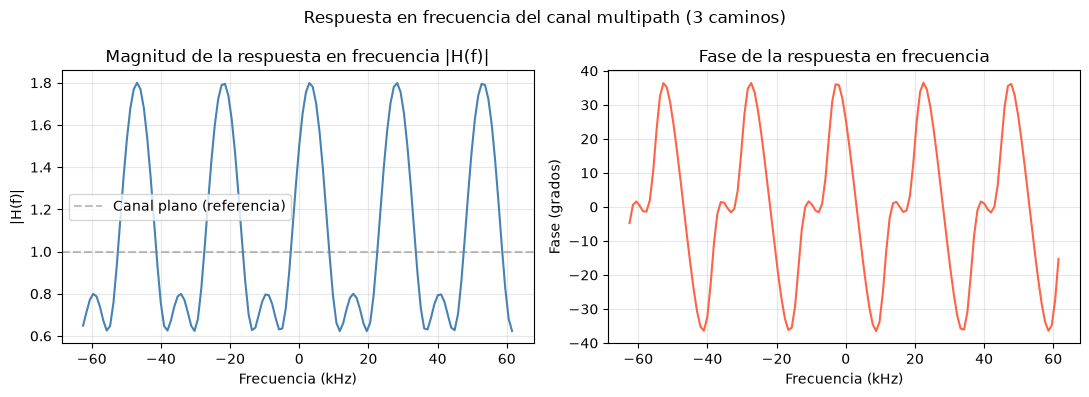

Ganancia máxima: 1.800
Ganancia mínima: 0.623
Variación total: 9.2 dB


In [3]:
# Calculamos la respuesta en frecuencia del canal
H = np.fft.fft(h, n=N)    # FFT de h con N puntos (igual que el chirp)
freqs = np.fft.fftfreq(N, d=1/Fs) / 1e3   # frecuencias en kHz

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

# Magnitud de la respuesta en frecuencia
axs[0].plot(np.fft.fftshift(freqs),
            np.fft.fftshift(np.abs(H)), color='steelblue')
axs[0].set_title("Magnitud de la respuesta en frecuencia |H(f)|")
axs[0].set_xlabel("Frecuencia (kHz)")
axs[0].set_ylabel("|H(f)|")
axs[0].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Canal plano (referencia)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Fase de la respuesta en frecuencia
axs[1].plot(np.fft.fftshift(freqs),
            np.fft.fftshift(np.angle(H) * 180 / np.pi), color='tomato')
axs[1].set_title("Fase de la respuesta en frecuencia")
axs[1].set_xlabel("Frecuencia (kHz)")
axs[1].set_ylabel("Fase (grados)")
axs[1].grid(True, alpha=0.3)

plt.suptitle("Respuesta en frecuencia del canal multipath (3 caminos)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Ganancia máxima: {np.max(np.abs(H)):.3f}")
print(f"Ganancia mínima: {np.min(np.abs(H)):.3f}")
print(f"Variación total: {20*np.log10(np.max(np.abs(H))/np.min(np.abs(H))):.1f} dB")

## 4. Función de canal selectivo en frecuencia

Aplicar el canal es convolucionar cada chirp con `h`.

In [4]:
def aplicar_canal_selectivo(waveform, h):
    """
    Aplica un canal multipath a una matriz de waveforms LoRa.

    Para cada chirp (fila de la matriz), convoluciona con la respuesta
    al impulso h del canal. Trunca el resultado a N muestras para
    mantener la estructura de la matriz.

    Parámetros
    ----------
    waveform : np.array complejo de shape (num_simbolos, N)
    h        : np.array complejo — respuesta al impulso del canal

    Retorna
    -------
    waveform_distorsionada : np.array complejo de shape (num_simbolos, N)
    """
    num_simbolos, N = waveform.shape
    waveform_dist = np.zeros((num_simbolos, N), dtype=complex)

    for i in range(num_simbolos):
        # Convolución del chirp con la respuesta al impulso del canal
        # np.convolve devuelve N + len(h) - 1 muestras en modo 'full'
        resultado_completo = np.convolve(waveform[i], h, mode='full')

        # Tomamos solo las primeras N muestras
        waveform_dist[i] = resultado_completo[:N]

    return waveform_dist

# Prueba: aplicamos el canal a un chirp y verificamos la shape
wf_prueba = waveform_former([45], SF, BW, Fs)
wf_canal  = aplicar_canal_selectivo(wf_prueba, h)
print(f"Shape entrada : {wf_prueba.shape}")
print(f"Shape salida  : {wf_canal.shape}  (se mantiene igual)")

Shape entrada : (1, 128)
Shape salida  : (1, 128)  (se mantiene igual)


## 5. Visualización: efecto del canal sobre un chirp

Comparamos la parte real del chirp original vs el chirp después del canal multipath.
La distorsión es visible: la señal ya no es un chirp limpio sino la suma
de varias copias retardadas y atenuadas.


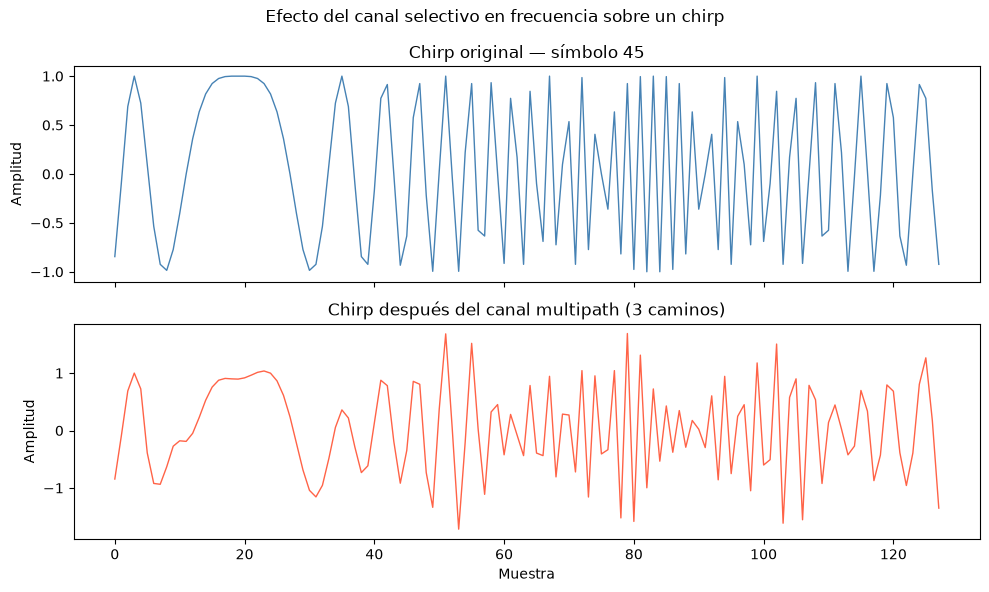

In [5]:
np.random.seed(3)
s_demo = 45
wf_limpio = waveform_former([s_demo], SF, BW, Fs)
wf_distorsionado = aplicar_canal_selectivo(wf_limpio, h)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(np.real(wf_limpio[0]), color='steelblue', linewidth=1)
axs[0].set_title(f"Chirp original — símbolo {s_demo}")
axs[0].set_ylabel("Amplitud")

axs[1].plot(np.real(wf_distorsionado[0]), color='tomato', linewidth=1)
axs[1].set_title(f"Chirp después del canal multipath (3 caminos)")
axs[1].set_ylabel("Amplitud")
axs[1].set_xlabel("Muestra")

plt.suptitle("Efecto del canal selectivo en frecuencia sobre un chirp", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Canal completo: multipath + AWGN

La cadena del canal real combina los dos efectos en orden:
1. Primero la señal pasa por el canal multipath.
2. Después se suma el ruido AWGN.

$$y[n] = (x[n] * h[n]) + w[n]$$


In [6]:
def canal_completo(waveform, h, snr_db):
    """
    Aplica canal multipath seguido de ruido AWGN.

    Parámetros
    ----------
    waveform : np.array complejo de shape (num_simbolos, N)
    h        : respuesta al impulso del canal multipath
    snr_db   : SNR del ruido AWGN en dB

    Retorna
    -------
    waveform_rx : np.array complejo con multipath + ruido
    """
    # Paso 1: distorsión por multipath
    waveform_multipath = aplicar_canal_selectivo(waveform, h)

    # Paso 2: ruido AWGN sobre la señal ya distorsionada
    waveform_rx = agregar_ruido_awgn(waveform_multipath, snr_db)

    return waveform_rx

print("Función canal_completo definida.")

Función canal_completo definida.


## 7. Barrido BER vs SNR — canal selectivo en frecuencia

Se repite el mismo barrido del Módulo 3 pero ahora con el canal completo
(multipath + AWGN) para poder comparar ambas curvas.


In [7]:
np.random.seed(99)

snr_range = np.arange(-15, 16, 1)
num_bits_por_punto = 70 * SF
ber_selectivo = []

print(f"{'SNR (dB)':>10} | {'BER selectivo':>15} | {'Errores/Total':>15}")
print("-" * 48)

for snr in snr_range:
    bits_tx = np.random.randint(0, 2, num_bits_por_punto)
    simbolos_tx = codificador(bits_tx, SF)

    # Modulación
    wf = waveform_former(simbolos_tx, SF, BW, Fs)

    # Canal completo: multipath + AWGN
    wf_rx = canal_completo(wf, h, snr)

    # Demodulación y decodificación
    simbolos_rx = n_tuple_former(wf_rx, SF, BW, Fs)
    bits_rx = decodificador(simbolos_rx, SF)

    ber = calcular_ber(bits_tx, bits_rx)
    ber_selectivo.append(ber)

    errores = int(ber * len(bits_tx))
    print(f"{snr:>10} | {ber:>15.6f} | {errores:>6} / {len(bits_tx)}")

ber_selectivo = np.array(ber_selectivo)

  SNR (dB) |   BER selectivo |   Errores/Total
------------------------------------------------
       -15 |        0.346939 |    170 / 490
       -14 |        0.314286 |    154 / 490
       -13 |        0.287755 |    141 / 490
       -12 |        0.191837 |     94 / 490
       -11 |        0.134694 |     66 / 490
       -10 |        0.124490 |     61 / 490
        -9 |        0.048980 |     24 / 490
        -8 |        0.000000 |      0 / 490
        -7 |        0.000000 |      0 / 490
        -6 |        0.004082 |      2 / 490
        -5 |        0.000000 |      0 / 490
        -4 |        0.000000 |      0 / 490
        -3 |        0.000000 |      0 / 490
        -2 |        0.000000 |      0 / 490
        -1 |        0.000000 |      0 / 490
         0 |        0.000000 |      0 / 490
         1 |        0.000000 |      0 / 490
         2 |        0.000000 |      0 / 490
         3 |        0.000000 |      0 / 490
         4 |        0.000000 |      0 / 490
         5 |        0.00

## 8. Curva BER vs SNR — comparación completa

Graficamos tres curvas en el mismo eje:
- **Canal AWGN puro** (Módulo 3): referencia base
- **Canal selectivo + AWGN** (Módulo 4): el efecto combinado
- **Referencia teórica** M-FSK no coherente

>ACHICAR RANGO Y CANTIDAD DE SIMBOLOS


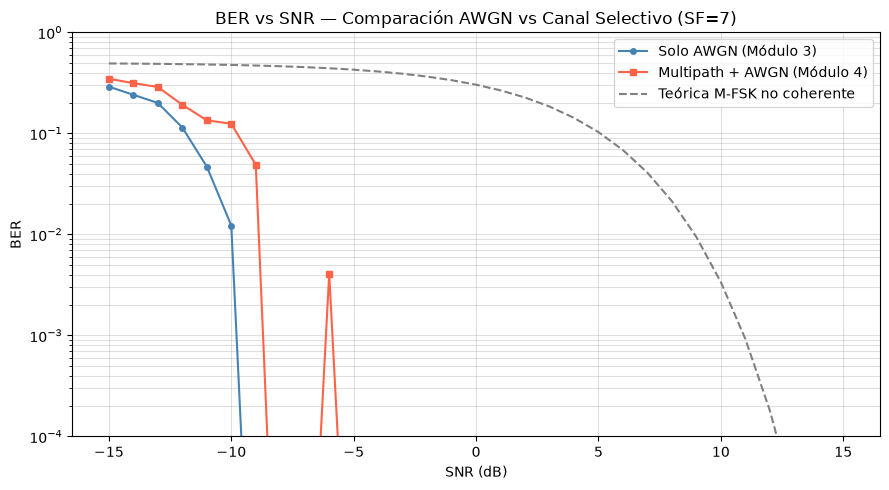

In [8]:
# Recalculamos la curva AWGN pura para comparar
np.random.seed(99)
ber_awgn = []
for snr in snr_range:
    bits_tx = np.random.randint(0, 2, num_bits_por_punto)
    simbolos_tx = codificador(bits_tx, SF)
    wf = waveform_former(simbolos_tx, SF, BW, Fs)
    wf_rx = agregar_ruido_awgn(wf, snr)
    simbolos_rx = n_tuple_former(wf_rx, SF, BW, Fs)
    bits_rx = decodificador(simbolos_rx, SF)
    ber_awgn.append(calcular_ber(bits_tx, bits_rx))
ber_awgn = np.array(ber_awgn)

# Curva teórica de referencia
snr_lineal = 10 ** (snr_range / 10)
ber_teo = (N/2)/(N-1) * ((N-1)/N) * np.exp(-snr_lineal / 2)

# Graficamos
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(snr_range, np.where(ber_awgn > 0, ber_awgn, 1e-7),
            marker='o', markersize=4, linewidth=1.5,
            color='steelblue', label='Solo AWGN (Módulo 3)')

ax.semilogy(snr_range, np.where(ber_selectivo > 0, ber_selectivo, 1e-7),
            marker='s', markersize=4, linewidth=1.5,
            color='tomato', label='Multipath + AWGN (Módulo 4)')

ax.semilogy(snr_range, ber_teo,
            linestyle='--', linewidth=1.5,
            color='gray', label='Teórica M-FSK no coherente')

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("BER")
ax.set_title(f"BER vs SNR — Comparación AWGN vs Canal Selectivo (SF={SF})")
ax.legend()
ax.grid(True, which='both', alpha=0.4)
ax.set_ylim(1e-4, 1)
plt.tight_layout()
plt.show()

## 9. Análisis de resultados

In [9]:
# SNR de corte para cada canal (BER < 1%)
def snr_corte(snr_range, ber_array, umbral=0.01):
    for snr, ber in zip(snr_range, ber_array):
        if ber < umbral:
            return snr
    return None

corte_awgn = snr_corte(snr_range, ber_awgn)
corte_sel  = snr_corte(snr_range, ber_selectivo)

print("=== Comparación de resultados ===")
print(f"Canal AWGN puro      — BER < 1% a partir de: {corte_awgn} dB")
print(f"Canal selectivo+AWGN — BER < 1% a partir de: {corte_sel} dB")

if corte_awgn is not None and corte_sel is not None:
    degradacion = corte_sel - corte_awgn
    print(f"Degradación por multipath: +{degradacion} dB de SNR necesario")

print()
print("BER a SNR = -5 dB:")
idx_m5 = list(snr_range).index(-5)
print(f"  AWGN puro      : {ber_awgn[idx_m5]:.6f}")
print(f"  Canal selectivo: {ber_selectivo[idx_m5]:.6f}")

=== Comparación de resultados ===
Canal AWGN puro      — BER < 1% a partir de: -9 dB
Canal selectivo+AWGN — BER < 1% a partir de: -8 dB
Degradación por multipath: +1 dB de SNR necesario

BER a SNR = -5 dB:
  AWGN puro      : 0.000000
  Canal selectivo: 0.000000
